# K-Nearest Neighbor Classification Mini Project
### Pattern Recognition & Machine Learning

This notebook implements a complete K-Nearest Neighbor (KNN) Classifier workflow using the Breast Cancer Wisconsin dataset. It covers data exploration, feature scaling, hyperparameter tuning via cross-validation, and rigorous model evaluation.

## 1. Dependencies & Environment Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Set random seed for strict reproducibility
np.random.seed(42)
print(np.random.seed(42))

None


## 2. Data Loading & Exploration

--- Loading Dataset ---
Dataset Shape: (569, 31)
Total Missing Values discovered: 0
Class Distribution:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


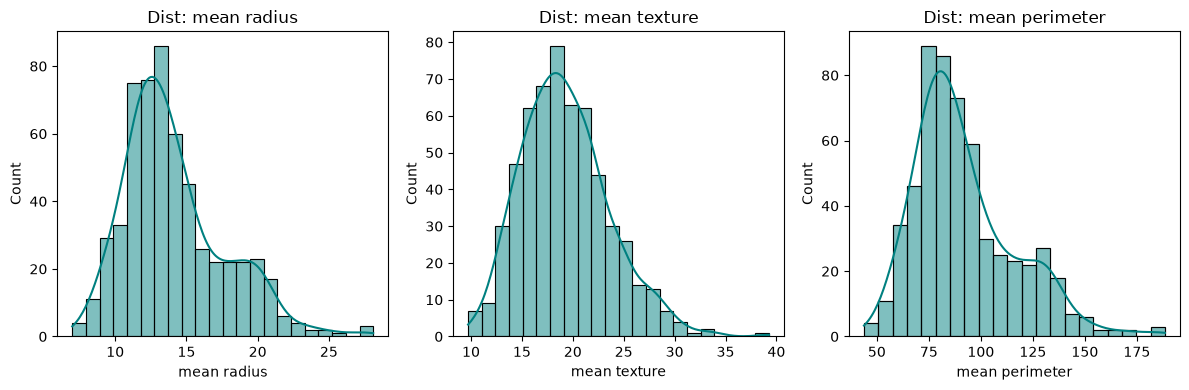

In [4]:
print("--- Loading Dataset ---")
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f"Dataset Shape: {df.shape}")
print(f"Total Missing Values discovered: {df.isnull().sum().sum()}")
print(f"Class Distribution:\n{df['target'].value_counts(normalize=True)}")

# Visualize feature distributions for the first few features
plt.figure(figsize=(12, 4))
for i, feature in enumerate(data.feature_names[:3]):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[feature], kde=True, color='teal')
    plt.title(f"Dist: {feature}")
plt.tight_layout()
plt.show()

## 3. Train-Test Split & Feature Scaling
KNN relies on distance metrics. Features with large scales can dominate distance calculations, making feature scaling with `StandardScaler` absolutely critical.

In [5]:
X = df.drop(columns=['target'])
y = df['target']

# 80/20 Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Apply StandardScaler to eliminate magnitude dominance issues
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Training set shape: (455, 30)
Testing set shape: (114, 30)


## 4. Hyperparameter Tuning ($k$) via Cross-Validation
We test odd values of $k$ from 1 to 11 using a loop and 5-fold cross-validation to discover the sweet spot between bias and variance, fulfilling the hyperparameter milestone.

k = 1 | Mean CV Accuracy: 0.9451
k = 3 | Mean CV Accuracy: 0.9692
k = 5 | Mean CV Accuracy: 0.9670
k = 7 | Mean CV Accuracy: 0.9692
k = 9 | Mean CV Accuracy: 0.9692
k = 11 | Mean CV Accuracy: 0.9626


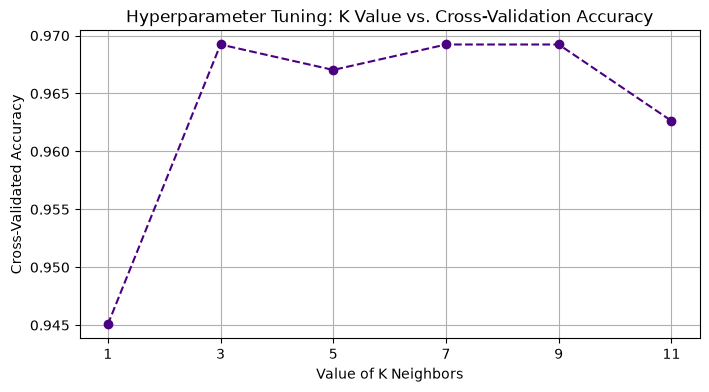

--> Optimal K identified via Cross-Validation: 3


In [6]:
k_values = [1, 3, 5, 7, 9, 11]
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f"k = {k} | Mean CV Accuracy: {scores.mean():.4f}")

# Plot k vs. Cross-Validation Accuracy
plt.figure(figsize=(8, 4))
plt.plot(k_values, cv_scores, marker='o', linestyle='--', color='indigo')
plt.xlabel('Value of K Neighbors')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Hyperparameter Tuning: K Value vs. Cross-Validation Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

optimal_k = k_values[np.argmax(cv_scores)]
print(f"--> Optimal K identified via Cross-Validation: {optimal_k}")

## 5. Final Model Evaluation & Predictions
Now, train the model using the optimal $k$ value found above and evaluate its performance against the unseen test dataset. This satisfies the milestone requiring a confusion matrix and full classification report.


### CLASSIFICATION REPORT ###
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Accuracy Score:  0.9825
Precision Score: 0.9730
Recall Score:    1.0000
F1 Score:        0.9863


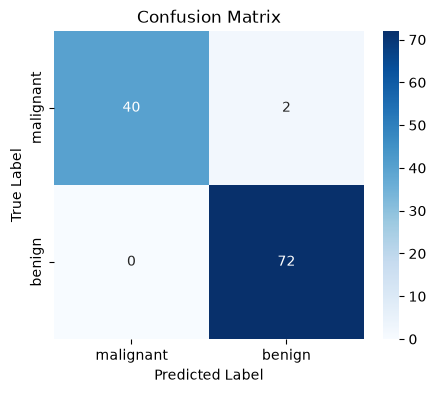

In [7]:
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train_scaled, y_train)
y_pred = final_knn.predict(X_test_scaled)

print("\n### CLASSIFICATION REPORT ###")
print(classification_report(y_test, y_pred, target_names=data.target_names))

print(f"Accuracy Score:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision Score: {precision_score(y_test, y_pred):.4f}")
print(f"Recall Score:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:        {f1_score(y_test, y_pred):.4f}")

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 6. Test Predictions on Unseen Sample (Inference)

In [10]:
print("--- Inference Pipeline Test ---")
mock_sample = np.mean(X_train, axis=0).to_numpy().reshape(1, -1)
mock_sample_scaled = scaler.transform(mock_sample)
prediction = final_knn.predict(mock_sample_scaled)
print(f"New Data Point Prediction: {data.target_names[prediction[0]]}")

--- Inference Pipeline Test ---
New Data Point Prediction: malignant


C:\Users\LUCA\Desktop\ML_ENV\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
